## Setup

### Import Required Packages

In [1]:
from recongraph.io_utils import file_writer, graph_generator
from recongraph.processors import graph_parser, graph_solver
from recongraph.visualizer import graph_visualizer
from pathlib import Path
import logging
from IPython.display import Image

In [2]:
logging.getLogger().setLevel(logging.WARN)
export_path = Path("../exports/")
if not export_path.exists():
    export_path.mkdir()

### Utility Functions

In [3]:
def viz_and_save(graph, path: Path, pos=None, bbox=None):
    file_writer.pygraphviz_export(graph, path.with_suffix(".pdf"))

    if not pos or not bbox:
        pass
        # pos, bbox = graph_visualizer.multipartite_layout_by_connections(graph)
        pos, bbox = graph_visualizer.pygraphviz_layout(graph)
    file_writer.inkscape_export(graph, path.with_suffix(".svg"), pos, bbox)
    # graph_visualizer.viz_dag(graph, pos)

In [4]:
import networkx as nx


def vis_graph(g):
    img, ag = nx.nx_agraph.view_pygraphviz(g, prog="dot", show=False)
    display(Image(filename=img))

In [5]:
import tempfile


def viz_agraph(g):
    ext = "png"
    suffix = f".{ext}"
    path = tempfile.NamedTemporaryFile(suffix=suffix, delete=False)

    # Write graph to file
    g.draw(path=path, prog='dot')
    path.close()

    display(Image(filename=path.name))

### Load Assembly

In [6]:
# Load Assembly
# assembly = graph_generator.graph_from_gh_csv("../assemblies/ReconSlab_Top-Connectivity.csv")
# assembly = graph_generator.graph_from_dot_file("../assemblies/simple.dot")
# assembly = nx.read_gml("../assemblies/exception2.gml")
# assembly = nx.read_gml("../assemblies/no_rdg.gml")
# assembly = graph_generator.graph_from_dot_file("../assemblies/simple.dot")
assembly = graph_generator.graph_from_dot_file("../assemblies/extended_scc.dot")
# assembly = nx.read_gml("../assemblies/extended.gml")

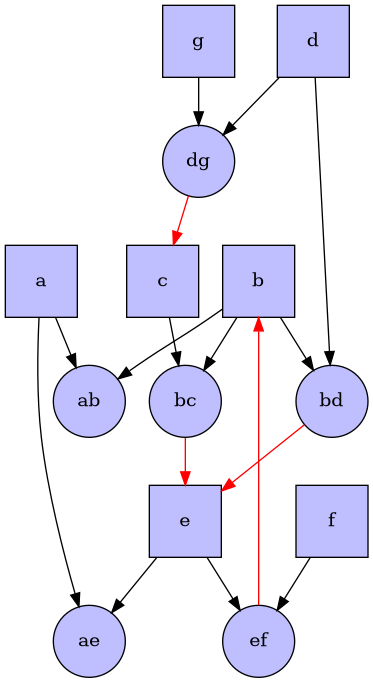

In [7]:
# viz_and_save(assembly, export_path / "01-dep.pdf")
vis_graph(assembly)

In [ ]:
resolved = graph_solver.resolve_dependencies(assembly)

In [ ]:
# viz_and_save(resolved, export_path / "RESOLVED.pdf")
vis_graph(resolved)

### Stages

In [ ]:
stages = graph_parser.add_stages(resolved)
components = graph_parser.add_components(resolved)

# Drafts

In [ ]:
kir = assembly.copy()

for e in kir.edges:
    kir[e[0]][e[1]]['capacity'] = 1

In [ ]:
nx.minimum_node_cut(kir, "d", "e")

ab {'TYPE': 'CONN'} ['a', 'b']
ae {'TYPE': 'CONN'} ['a', 'e']
bc {'TYPE': 'CONN'} ['b', 'c']
bd {'TYPE': 'CONN'} ['b', 'd']
dg {'TYPE': 'CONN'} ['d', 'g']
ef {'TYPE': 'CONN'} ['e', 'f']
Graph named 'SIMPLE' with 7 nodes and 6 edges
[('a', 'b', {'capacity': 1, 'collision': []}), ('a', 'e', {'capacity': 1, 'collision': []}), ('b', 'c', {'capacity': inf, 'collision': ['e']}), ('b', 'd', {'capacity': inf, 'collision': ['e']}), ('d', 'g', {'capacity': inf, 'collision': ['c']}), ('e', 'f', {'capacity': inf, 'collision': ['b']})]


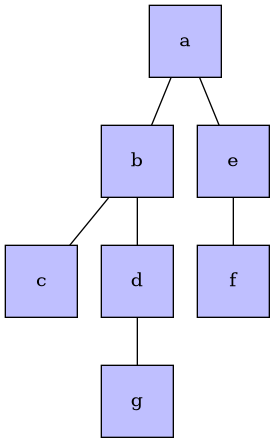

In [62]:
assembly_simple = assembly.copy()

for node, data in assembly.nodes.data():
    if data['TYPE'] == 'CONN':
        print(node, data, list(assembly.predecessors(node)))
        assembly_simple.remove_node(node)
        cap = float('inf') if assembly.out_degree[node] else 1
        assembly_simple.add_edge(*assembly.predecessors(node), capacity=cap, collision=list(assembly.neighbors(node)))

assembly_simple = assembly_simple.to_undirected()
print(assembly_simple)
print(assembly_simple.edges.data())
vis_graph(assembly_simple)

In [78]:
for u, v, data in assembly_simple.edges.data():
    print()
    print(u, v, data)
    if data["capacity"] == float('inf'):
        tmp_graph = nx.contracted_nodes(assembly_simple, u, v, self_loops=False)
        collision = data["collision"][0]
        print(tmp_graph)
        print(u, collision)
        new_cap = nx.minimum_cut(tmp_graph, u, collision)
        print(new_cap)


a b {'capacity': 1, 'collision': []}

a e {'capacity': 1, 'collision': []}

b c {'capacity': inf, 'collision': ['e']}
Graph named 'SIMPLE' with 6 nodes and 5 edges
b e
(1, ({'g', 'b', 'd', 'a'}, {'f', 'e'}))

b d {'capacity': inf, 'collision': ['e']}
Graph named 'SIMPLE' with 6 nodes and 5 edges
b e
(1, ({'g', 'c', 'b', 'a'}, {'f', 'e'}))

d g {'capacity': inf, 'collision': ['c']}
Graph named 'SIMPLE' with 6 nodes and 5 edges
d c


NetworkXUnbounded: Infinite capacity path, flow unbounded above.

In [71]:
nx.minimum_cut(assembly_simple, 'f', 'e')

NetworkXUnbounded: Infinite capacity path, flow unbounded above.

In [69]:
nx.minimum_edge_cut(assembly_simple, 'f', 'e')

{('f', 'e')}